In [1]:
import sys
from pathlib import Path
# Get project root (current working directory when running from project root)
# If running from research/, use parent; otherwise use cwd()
project_root = Path.cwd() if (Path.cwd() / 'vault').exists() else Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
from utils.enums import Ticker, TimeFrame, Direction
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from feature_extraction.feature_extractor import extract_features
from feature_selection.base_models import BaseModel, QuantileBinningModel
from ensemble.vault_manager import (
    initialize_vault, create_ensemble_directory, 
    load_feature_base_models, list_features
)
from eda.feature_explorer import FeatureExplorer
import utils.helpers as helpers

/home/raman/repos/Trading-Algo/utils/permutation_test/permute_bars.py:38: UserWarning: feature_selection.opt_thresh not found. Using simplified threshold optimization. For full functionality, ensure the opt_thresh module is available.
  warnings.warn(


# Buy and Hold Bias Node - Vault Integration Test

This notebook demonstrates:
1. Extracting the buy_hold feature (always outputs 1.0)
2. Visualizing the feature and comparing with returns
3. Creating a BaseModel with binning
4. Saving to vault as an end-to-end integration test

In [3]:
# Step 1: Extract buy_hold feature
features, targets = extract_features(
    module_name='buy_hold',
    params={},
    ticker=Ticker.ES,
    start=datetime(2020, 1, 1),
    end=datetime(2024, 12, 31),
    timeframes=[TimeFrame.D]
)

print(f"Features shape: {features.shape}")
print(f"Targets shape: {targets.shape}")
print(f"\nFeature columns: {list(features.columns)}")
print(f"\nFirst few feature values:")
print(features.head())

Features shape: (1260, 1)
Targets shape: (1260, 4)

Feature columns: ['buy_hold_signal_D']

First few feature values:
                           buy_hold_signal_D
datetime                                    
2020-01-02 00:00:00+00:00                1.0
2020-01-03 00:00:00+00:00                1.0
2020-01-06 00:00:00+00:00                1.0
2020-01-07 00:00:00+00:00                1.0
2020-01-08 00:00:00+00:00                1.0


/home/raman/repos/Trading-Algo/metrics/plotting/distribution.py:96: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(p1 - margin, p99 + margin)


FeatureExplorer created successfully!
  Number of features: 1
  Feature names: ['buy_hold_signal_D']
  Number of samples: 1260

Plotting distributions for 1 features

[1/1] buy_hold_signal_D
  ✓ Complete

Completed 1/1 features


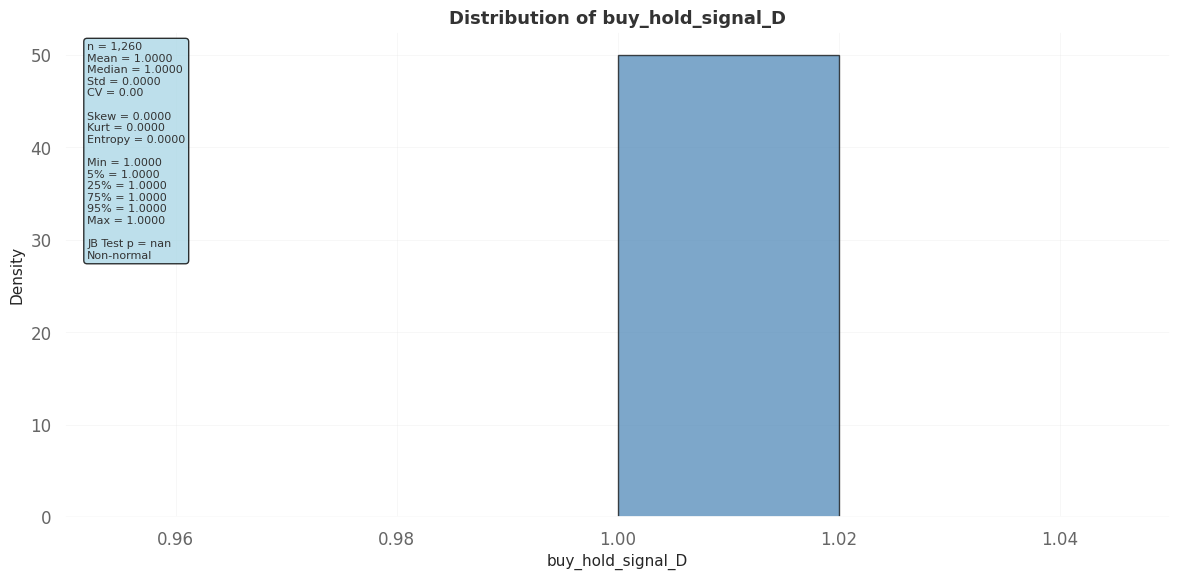


Plotting time series for 1 features

[1/1] buy_hold_signal_D


/home/raman/repos/Trading-Algo/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


  ✓ Complete

Completed 1/1 features


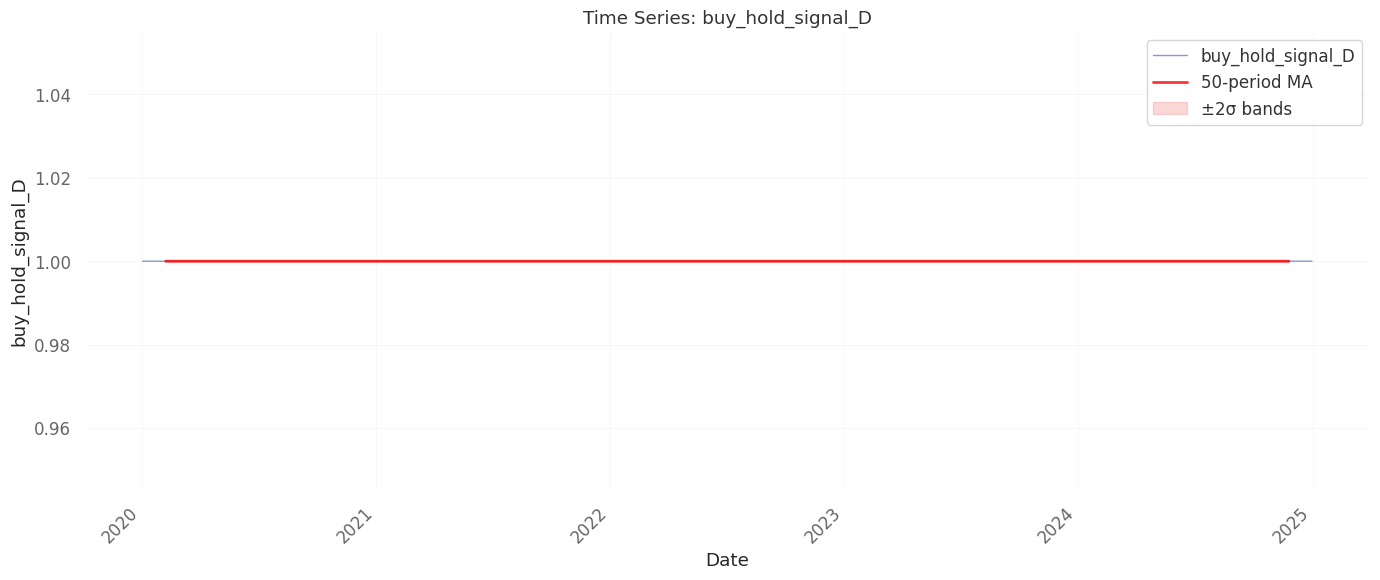


Plotting decile analysis for 1 features
Target: log_return

[1/1] buy_hold_signal_D
  ✓ Complete

Completed 1/1 features


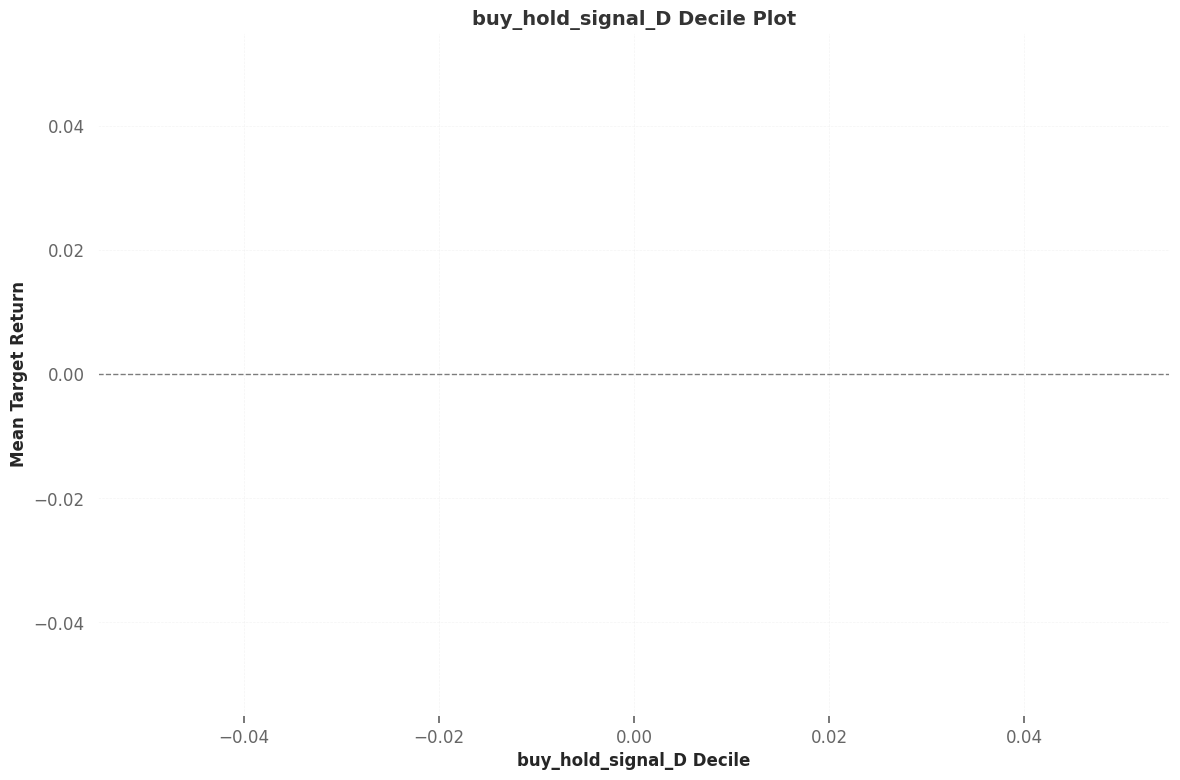


Feature statistics for buy_hold_signal_D:
  Min: 1.0
  Max: 1.0
  Mean: 1.0
  Unique values: 1
  All values == 1.0: True


In [4]:
# Step 2: Create FeatureExplorer and visualize
# Build metadata for FeatureExplorer compatibility
metadata = {'feature_metadata': {}}
for col in features.columns:
    if col != 'ticker':
        try:
            parsed = helpers.parse_feature_column_name(col)
            metadata['feature_metadata'][col] = {
                'module': parsed.get('module'),
                'parameters': parsed.get('params', {}),
                'timeframes': [parsed.get('tf')] if parsed.get('tf') else [],
                'base_name': parsed.get('module'),
                'full_name': col
            }
        except:
            metadata['feature_metadata'][col] = {
                'module': None,
                'parameters': {},
                'timeframes': [],
                'base_name': None,
                'full_name': col
            }

explorer = FeatureExplorer(
    features_df=features,
    targets_df=targets,
    metadata=metadata
)

print("FeatureExplorer created successfully!")
print(f"  Number of features: {explorer.n_features}")
print(f"  Feature names: {explorer.feature_names}")
print(f"  Number of samples: {explorer.n_samples}")

# Plot distributions and timeseries
explorer.plot_distributions(bins=50)
plt.show()

explorer.plot_timeseries(rolling_window=50)
plt.show()

# Plot decile analysis
figs = explorer.plot_all_deciles(n_bins=4, target_col='log_return')
plt.show()

# Verify feature is constant (buy_hold should always be 1.0)
feature_col = explorer.feature_names[0]  # Should be buy_hold_signal_D
feature_series = features[feature_col]
print(f"\nFeature statistics for {feature_col}:")
print(f"  Min: {feature_series.min()}")
print(f"  Max: {feature_series.max()}")
print(f"  Mean: {feature_series.mean()}")
print(f"  Unique values: {feature_series.nunique()}")
print(f"  All values == 1.0: {(feature_series == 1.0).all()}")

In [5]:
# Step 3: Load candles data for BaseModel.fit()
# BaseModel.fit() requires candles_df with columns: datetime, open, high, low, close, volume, ticker, timeframe
raw_candles = helpers.load_data(
    ticker=Ticker.ES,
    timeframe=TimeFrame.D,
    start=datetime(2020, 1, 1),
    end=datetime(2024, 12, 31)
)

# Reset index to get datetime as column
candles_df = raw_candles.reset_index()
candles_df['ticker'] = Ticker.ES
candles_df['timeframe'] = TimeFrame.D

# Use standardized alignment helper to match features index
# This ensures datetime alignment and returns datetime as column (for BaseModel.fit)
candles_df = helpers.align_candles_with_features(candles_df, features)

print(f"Candles shape: {candles_df.shape}")
print(f"Candles columns: {list(candles_df.columns)}")
print(f"\nFirst few candles:")
print(candles_df.head())

Candles shape: (1260, 9)
Candles columns: ['datetime', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'timeframe']

First few candles:
                   datetime   timestamp     open     high      low    close  \
0 2020-01-02 00:00:00+00:00  1577923200  3237.00  3261.75  3234.25  3259.00   
1 2020-01-03 00:00:00+00:00  1578009600  3261.00  3263.50  3206.75  3235.50   
2 2020-01-06 00:00:00+00:00  1578268800  3220.25  3249.50  3208.75  3243.50   
3 2020-01-07 00:00:00+00:00  1578355200  3243.50  3254.50  3226.00  3235.25   
4 2020-01-08 00:00:00+00:00  1578441600  3231.75  3267.75  3181.00  3260.25   

    volume     ticker    timeframe  
0  1416241  Ticker.ES  TimeFrame.D  
1  1684630  Ticker.ES  TimeFrame.D  
2  1502748  Ticker.ES  TimeFrame.D  
3  1293494  Ticker.ES  TimeFrame.D  
4  2279138  Ticker.ES  TimeFrame.D  


In [6]:
# Step 4: Create and fit BaseModel
# Use n_bins=2 (minimum that works with binning logic)
# Since buy_hold always outputs 1.0, it will be a constant feature
binning_model = QuantileBinningModel(n_bins=2, selection_metric='sortino', strategy='long')

bias_spec = {
    'module_name': 'buy_hold',
    'timeframes': [TimeFrame.D],
    'params': {}
}

base_model = BaseModel(
    bias_node_spec=bias_spec,
    binning_model=binning_model,
    ticker=Ticker.ES
)

# Prepare target data aligned with candles
# BaseModel.fit expects target_data as Series with datetime index
# Align targets with candles datetime column
candles_indexed = candles_df.set_index('datetime')
target_series = targets['log_return'].reindex(candles_indexed.index).dropna()

# Fit model
print("Fitting BaseModel...")
base_model.fit(candles_df, target_series)
print(f"✓ Model fitted successfully!")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Binning model fitted: {base_model.binning_model.is_fitted_}")
print(f"  Best long bin: {base_model.binning_model.best_long_bin_}")
print(f"  Thresholds: {base_model.binning_model.thresholds_}")

# Visualize signal performance using FeatureExplorer
from metrics.performance import SortinoRatio
metric = SortinoRatio(annualization_factor=252)

figs, summary = explorer.plot_signal_cumsum(
    target_col='log_return',
    base_model=base_model,
    show_plot=True,
    metric=metric,
    strategy='long'
)
plt.show()

print("\nSignal Performance Summary:")
print(summary)

Fitting BaseModel...
✓ Model fitted successfully!
  Feature column: buy_hold_signal_D
  Binning model fitted: True
  Best long bin: 0
  Thresholds: []

Plotting signal-gated cumulative returns for 1 features
Target: log_return | Strategy: long

[1/1] buy_hold_signal_D
  ✗ Failed: 'Series' object has no attribute 'iterrows'

Signal Performance Summary:
Empty DataFrame
Columns: []
Index: []


In [7]:
# Step 5: Test predictions (should always be 1 for buy and hold)
test_candles = candles_df.tail(100)  # Last 100 candles
predictions = base_model.predict(test_candles, strategy='long')

print(f"Predictions shape: {predictions.shape}")
print(f"Unique prediction values: {np.unique(predictions)}")
print(f"All predictions == 1: {(predictions == 1).all()}")
print(f"\nFirst 10 predictions:")
print(predictions.head(10))

Predictions shape: (0,)
Unique prediction values: []
All predictions == 1: True

First 10 predictions:
Series([], dtype: int64)


In [8]:
# Step 6: Save to vault
print("Initializing vault...")
# Use absolute path to ensure vault is created in project root, not research/
vault_root = str(project_root / 'vault')
initialize_vault(vault_root)

print("Creating ensemble directory...")
ensemble_dir = create_ensemble_directory(
    vault_root=vault_root,
    timeframe=TimeFrame.D,
    ensemble_name='buy_hold',
    direction=Direction.LONG
)

print(f"✓ Created ensemble directory: {ensemble_dir}")

Initializing vault...
Creating ensemble directory...
✓ Created ensemble directory: /home/raman/repos/Trading-Algo/vault/D/buy_hold_long


In [9]:


print("\nSaving base model to vault...")
model_id = base_model.save_to_vault(ensemble_dir)
print(f"✓ Saved model with ID: {model_id}")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Model ID: {model_id}")


Saving base model to vault...
✓ Saved model with ID: quantile_binning_2
  Feature column: buy_hold_signal_D
  Model ID: quantile_binning_2


In [10]:
# Step 7: Verify vault save/load
print("Loading models from vault...")
loaded_models = load_feature_base_models(
    ensemble_dir=ensemble_dir,
    feature_column=base_model.feature_column
)
model_id = 'quantile_binning_2'

print(f"✓ Loaded {len(loaded_models)} model(s)")
print(f"  Model IDs: {list(loaded_models.keys())}")

# Verify loaded model
if model_id in loaded_models:
    loaded_model = loaded_models[model_id]
    print(f"\n✓ Model '{model_id}' loaded successfully")
    print(f"  Binning model fitted: {loaded_model.binning_model.is_fitted_}")
    print(f"  Best long bin: {loaded_model.binning_model.best_long_bin_}")
    
    # Test predictions with loaded model
    test_predictions = loaded_model.predict(test_candles, strategy='long')
    print(f"  Predictions from loaded model all == 1: {(test_predictions == 1).all()}")

# List all features in ensemble
print("\n" + "="*70)
print("Features in ensemble:")
print("="*70)
features_df = list_features(ensemble_dir)
print(features_df)

Loading models from vault...
✓ Loaded 1 model(s)
  Model IDs: ['quantile_binning_2']

✓ Model 'quantile_binning_2' loaded successfully
  Binning model fitted: True
  Best long bin: 0
  Predictions from loaded model all == 1: True

Features in ensemble:
        feature_name     feature_column  n_base_models  n_fitted  \
0  buy_hold_signal_D  buy_hold_signal_D              1         1   

                         created_at                        updated_at  
0  2026-01-19T01:24:39.563625+00:00  2026-01-19T01:24:39.563647+00:00  
